# Imports

In [407]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np

# Rainfall 2021-2025

In [408]:
df_rainfall_2021_2025=pd.read_csv(r"Datasets\Rainfall\TamilNadu_Rainfall_Hourly_Telemetry_2021_2025_Truncated.csv")
df_rainfall_2021_2025.head()

,Unnamed: 0,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
0,0,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,09-01-2022 14:00,2.0
1,1,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,09-01-2022 15:00,15.0
2,2,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,09-01-2022 17:00,0.5
3,3,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,17-01-2022 17:00,0.5
4,4,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,12-02-2022 18:00,0.5


In [409]:
df_rainfall_2021_2025.drop(columns=['Unnamed: 0'],inplace=True)
df_rainfall_2021_2025.rename(columns={'Telemetry Hourly Rainfall (mm)':'Hourly Rainfall'},inplace=True)

In [410]:
df_rainfall_2021_2025['Data Acquisition Time']=pd.to_datetime(df_rainfall_2021_2025['Data Acquisition Time'],format='%d-%m-%Y %H:%M')
df_rainfall_2021_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 161593 entries, 0 to 161592
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Station                161593 non-null  str           
 1   District LGD Code      161593 non-null  int64         
 2   District               161593 non-null  str           
 3   Tehsil                 161593 non-null  str           
 4   Block                  161593 non-null  str           
 5   Village                161593 non-null  str           
 6   Latitude               161593 non-null  float64       
 7   Longitude              161593 non-null  float64       
 8   Data Acquisition Time  161593 non-null  datetime64[us]
 9   Hourly Rainfall        161593 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(5)
memory usage: 12.3 MB


# Rainfall 2026-2030

In [411]:
df_rainfall_2026_2030=pd.read_csv(r"Datasets\Rainfall\TamilNadu_Rainfall_Hourly_Telemetry_2026_2030.csv")
df_rainfall_2026_2030.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
0,1,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,25-02-2026 14:00,2.5
1,2,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,25-02-2026 15:00,0.5
2,3,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,27-02-2026 00:00,1.0
3,4,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,27-02-2026 14:00,1.0
4,5,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,27-02-2026 15:00,4.0


In [412]:
df_rainfall_2026_2030.drop(columns=['SlNo','Agency','State','State LGD Code','River','Basin','Tributary','Subtributary','SubSubtributary','Local River'],inplace=True)
df_rainfall_2026_2030.rename(columns={'Telemetry Hourly Rainfall (mm)':'Hourly Rainfall'},inplace=True)
df_rainfall_2026_2030['Data Acquisition Time']=pd.to_datetime(df_rainfall_2026_2030['Data Acquisition Time'],format='%d-%m-%Y %H:%M')
df_rainfall_2026_2030.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Hourly Rainfall
0,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2026-02-25 14:00:00,2.5
1,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2026-02-25 15:00:00,0.5
2,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2026-02-27 00:00:00,1.0
3,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2026-02-27 14:00:00,1.0
4,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2026-02-27 15:00:00,4.0


In [413]:
assert(df_rainfall_2021_2025.columns.all() == df_rainfall_2026_2030.columns.all())

In [414]:
df_rainfall_2021_2025['Data Acquisition Time'].describe()

count                        161593
mean     2024-03-08 09:22:42.907428
min             2021-08-09 14:00:00
25%             2023-05-02 05:00:00
50%             2024-05-16 06:15:00
75%             2024-12-12 23:00:00
max             2025-12-31 23:00:00
Name: Data Acquisition Time, dtype: object

In [415]:
df_rainfall_2026_2030['Data Acquisition Time'].describe()

count                          2935
mean     2026-01-30 09:18:01.839863
min             2026-01-01 00:00:00
25%             2026-01-11 16:00:00
50%             2026-01-20 15:00:00
75%             2026-02-05 05:30:00
max             2026-03-28 17:00:00
Name: Data Acquisition Time, dtype: object

# Rainfall 2021-2030

In [416]:
df_rainfall_2021_2030=pd.merge(df_rainfall_2021_2025,df_rainfall_2026_2030,how='outer')
df_rainfall_2021_2030.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Hourly Rainfall
0,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2022-01-09 14:00:00,2.0
1,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2022-01-09 15:00:00,15.0
2,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2022-01-09 17:00:00,0.5
3,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2022-01-17 17:00:00,0.5
4,Anaikidangu,575,Kanyakumari,-,-,-,8.2347,77.377894,2022-02-12 18:00:00,0.5


In [417]:
df_rainfall_2021_2030['Data Acquisition Time'].describe()

count                        164528
mean     2024-03-20 18:04:26.130385
min             2021-08-09 14:00:00
25%             2023-05-03 22:00:00
50%             2024-05-19 19:52:30
75%             2024-12-20 10:00:00
max             2026-03-28 17:00:00
Name: Data Acquisition Time, dtype: object

In [418]:
assert(df_rainfall_2021_2030.shape[0] == df_rainfall_2021_2025.shape[0]+df_rainfall_2026_2030.shape[0])

In [419]:
df_rainfall_2021_2030.sort_values(by=['Data Acquisition Time','District LGD Code'],inplace=True)

# Groundwater 2021-2025

In [420]:
df_groundwater_2021_2025=pd.read_csv(r"Datasets/Ground Water Level/TamilNadu_Ground_Water_Level_Daily_2021_2025.csv")
df_groundwater_2021_2025.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Groundwater Level Telemetry 6 Hourly (meter)
0,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,09-11-2023 13:34,-1.46
1,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,09-11-2023 13:37,-1.45
2,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,09-11-2023 18:00,-1.50
3,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,10-11-2023 00:00,-1.49
4,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,10-11-2023 06:00,-1.45


In [421]:
#df_groundwater_2021_2025.drop(columns=['SlNo','Agency','State','State LGD Code','River','Basin','Tributary','Subtributary','SubSubtributary','Local River','RL_MSL'],inplace=True)
df_groundwater_2021_2025['Data Acquisition Time']=pd.to_datetime(df_groundwater_2021_2025['Data Acquisition Time'],format='%d-%m-%Y %H:%M')
df_groundwater_2021_2025.rename(columns={'Groundwater Level Telemetry 6 Hourly (meter)':'Ground Water Level'},inplace=True)
df_groundwater_2021_2025.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Ground Water Level
0,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2023-11-09 13:34:00,-1.46
1,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2023-11-09 13:37:00,-1.45
2,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2023-11-09 18:00:00,-1.50
3,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2023-11-10 00:00:00,-1.49
4,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2023-11-10 06:00:00,-1.45


# Groundwater 2026-2030

In [422]:
df_groundwater_2026_2030=pd.read_csv(r"Datasets/Ground Water Level/TamilNadu_Ground_Water_Level_Daily_2026_2030.csv")
df_groundwater_2026_2030.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,...,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,RL_MSL,Data Acquisition Time,Groundwater Level Telemetry 6 Hourly (meter)
0,1,Adhamangalampudur,Tamil Nadu SW GW,33,Tamil Nadu,593,Thiruvannamalai,-,-,-,...,-,-,-,-,-,12.475914,78.990568,NaN,01-01-2026 00:00,-1.98
1,2,Adhamangalampudur,Tamil Nadu SW GW,33,Tamil Nadu,593,Thiruvannamalai,-,-,-,...,-,-,-,-,-,12.475914,78.990568,NaN,01-01-2026 06:00,-1.96
2,3,Adhamangalampudur,Tamil Nadu SW GW,33,Tamil Nadu,593,Thiruvannamalai,-,-,-,...,-,-,-,-,-,12.475914,78.990568,NaN,01-01-2026 12:00,-1.96
3,4,Adhamangalampudur,Tamil Nadu SW GW,33,Tamil Nadu,593,Thiruvannamalai,-,-,-,...,-,-,-,-,-,12.475914,78.990568,NaN,01-01-2026 18:00,-2.00
4,5,Adhamangalampudur,Tamil Nadu SW GW,33,Tamil Nadu,593,Thiruvannamalai,-,-,-,...,-,-,-,-,-,12.475914,78.990568,NaN,02-01-2026 00:00,-1.98


In [423]:
df_groundwater_2026_2030.drop(columns=['SlNo','Agency','State','State LGD Code','River','Basin','Tributary','Subtributary','SubSubtributary','Local River','RL_MSL'],inplace=True)
df_groundwater_2026_2030.rename(columns={'Groundwater Level Telemetry 6 Hourly (meter)':'Ground Water Level'},inplace=True)
df_groundwater_2026_2030['Data Acquisition Time']=pd.to_datetime(df_groundwater_2026_2030['Data Acquisition Time'],format='%d-%m-%Y %H:%M')
df_groundwater_2026_2030.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Ground Water Level
0,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2026-01-01 00:00:00,-1.98
1,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2026-01-01 06:00:00,-1.96
2,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2026-01-01 12:00:00,-1.96
3,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2026-01-01 18:00:00,-2.00
4,Adhamangalampudur,593,Thiruvannamalai,-,-,-,12.475914,78.990568,2026-01-02 00:00:00,-1.98


# Groundwater 2021-2030

In [424]:
df_groundwater_2021_2030=pd.merge(df_groundwater_2021_2025,df_groundwater_2026_2030,how='outer')
df_groundwater_2021_2030.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Ground Water Level
0,A.Pudupatti,591,Tiruchirappalli,-,-,-,10.46611,78.54556,2024-05-22 11:41:00,1.000
1,A.Pudupatti,591,Tiruchirappalli,-,-,-,10.46611,78.54556,2024-05-22 11:44:00,1.000
2,A.Velampatti,571,Dharmapuri,HARUR,-,-,12.16110,78.43420,2021-01-01 00:00:00,-8.352
3,A.Velampatti,571,Dharmapuri,HARUR,-,-,12.16110,78.43420,2021-01-01 06:00:00,-8.308
4,A.Velampatti,571,Dharmapuri,HARUR,-,-,12.16110,78.43420,2021-01-01 12:00:00,-8.317


In [425]:
df_groundwater_2021_2030['Data Acquisition Time'].describe()

count                       1138888
mean     2023-11-10 19:55:55.326388
min             2021-01-01 00:00:00
25%             2022-08-24 18:00:00
50%             2024-02-29 12:00:00
75%             2025-01-28 00:00:00
max             2026-03-28 12:17:00
Name: Data Acquisition Time, dtype: object

In [426]:
df_groundwater_2021_2030.sort_values(by=['Data Acquisition Time','District LGD Code'],inplace=True)
df_groundwater_2021_2030.head()

,Station,District LGD Code,District,Tehsil,Block,Village,Latitude,Longitude,Data Acquisition Time,Ground Water Level
157658,Athinarayanapuram,569,Coimbatore,Sulur,-,-,11.051390,77.086700,2021-01-01,-13.312
83788,Anna Grammam,570,Cuddalore,PANRUTI,-,-,11.788056,79.601944,2021-01-01,-6.382
303971,Chidambaram,570,Cuddalore,CHIDAMBARAM,-,-,11.392222,79.701944,2021-01-01,-6.924
361320,Cuddalore - OT,570,Cuddalore,CUDDALORE,-,-,11.713889,79.772222,2021-01-01,-20.510
918710,Keelpalaiyur,570,Cuddalore,Vriddhachalam,-,-,11.465833,79.423889,2021-01-01,-34.836


# Final Dataset

In [427]:
rainfall = (
    df_rainfall_2021_2030
    .groupby(['Data Acquisition Time', 'District LGD Code','District'])
    ['Hourly Rainfall']
    .mean()
    .reset_index()
)

In [428]:
groundwater = (
    df_groundwater_2021_2030
    .groupby(['Data Acquisition Time', 'District LGD Code'])
    ['Ground Water Level']
    .mean()
    .reset_index()
)

In [429]:
df=pd.merge(rainfall,groundwater,on=['Data Acquisition Time','District LGD Code'],how='inner')
df = df.sort_values(['District LGD Code','Data Acquisition Time'])
df.head()

,Data Acquisition Time,District LGD Code,District,Hourly Rainfall,Ground Water Level
5332,2023-11-03 12:00:00,568,Chennai,7.50,-4.10
5390,2023-11-04 18:00:00,568,Chennai,4.00,-3.94
5586,2023-11-09 18:00:00,568,Chennai,0.50,-3.93
5686,2023-11-14 00:00:00,568,Chennai,7.75,-3.95
5716,2023-11-14 12:00:00,568,Chennai,2.25,-3.93


In [430]:
df['day']=df['Data Acquisition Time'].dt.day
df['month']=df['Data Acquisition Time'].dt.month
df['year']=df['Data Acquisition Time'].dt.year

# EDA

In [431]:
df.info()

<class 'pandas.DataFrame'>
Index: 14343 entries, 5332 to 14313
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Data Acquisition Time  14343 non-null  datetime64[us]
 1   District LGD Code      14343 non-null  int64         
 2   District               14343 non-null  str           
 3   Hourly Rainfall        14343 non-null  float64       
 4   Ground Water Level     14343 non-null  float64       
 5   day                    14343 non-null  int32         
 6   month                  14343 non-null  int32         
 7   year                   14343 non-null  int32         
dtypes: datetime64[us](1), float64(2), int32(3), int64(1), str(1)
memory usage: 840.4 KB


In [432]:
df.isnull().sum()

Data Acquisition Time    0
District LGD Code        0
District                 0
Hourly Rainfall          0
Ground Water Level       0
day                      0
month                    0
year                     0
dtype: int64

In [433]:
df.duplicated().sum()

np.int64(0)

In [434]:
Q1 = df['Hourly Rainfall'].quantile(0.25)
Q3 = df['Hourly Rainfall'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_rainfall = df[(df['Hourly Rainfall'] < lower_bound) | (df['Hourly Rainfall'] > upper_bound)]
print(f"Number of Outliers in 'Hourly Rainfall': {outliers_rainfall.shape[0]}")
outliers_rainfall.head()

Number of Outliers in 'Hourly Rainfall': 1997


,Data Acquisition Time,District LGD Code,District,Hourly Rainfall,Ground Water Level,day,month,year
5332,2023-11-03 12:00:00,568,Chennai,7.50,-4.10,3,11,2023
5686,2023-11-14 00:00:00,568,Chennai,7.75,-3.95,14,11,2023
7507,2024-06-10 18:00:00,568,Chennai,9.75,-5.29,10,6,2024
7834,2024-07-06 00:00:00,568,Chennai,22.75,-4.62,6,7,2024
7909,2024-07-13 00:00:00,568,Chennai,11.75,-4.48,13,7,2024


In [435]:
Q1 = df['Ground Water Level'].quantile(0.25)
Q3 = df['Ground Water Level'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_ground_water = df[(df['Ground Water Level'] < lower_bound) | (df['Ground Water Level'] > upper_bound)]
print(f"Number of Outliers in 'Ground Water Level': {outliers_ground_water.shape[0]}")
outliers_ground_water.head()

Number of Outliers in 'Ground Water Level': 1630


,Data Acquisition Time,District LGD Code,District,Hourly Rainfall,Ground Water Level,day,month,year
7059,2024-05-19 06:00:00,571,Dharmapuri,0.50,-41.166357,19,5,2024
10781,2024-12-27 00:00:00,571,Dharmapuri,0.50,-32.749182,27,12,2024
116,2021-12-31 18:00:00,572,Dindigul,0.75,-87.381417,31,12,2021
129,2022-01-01 18:00:00,572,Dindigul,0.50,-87.302500,1,1,2022
133,2022-01-02 00:00:00,572,Dindigul,6.75,-87.282667,2,1,2022


<Axes: xlabel='District'>

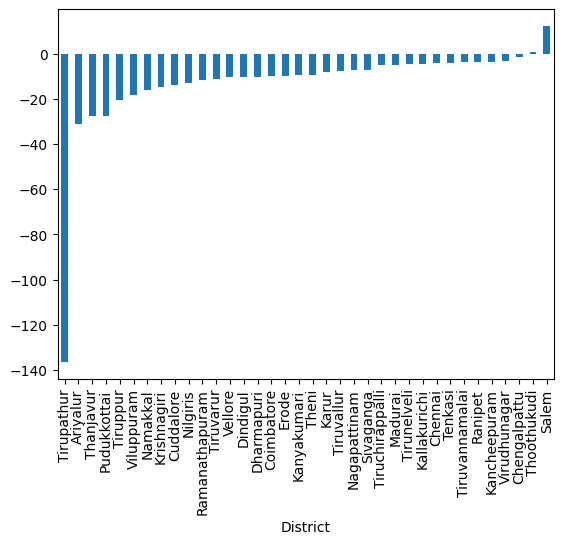

In [436]:
df.groupby('District')['Ground Water Level'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='District'>

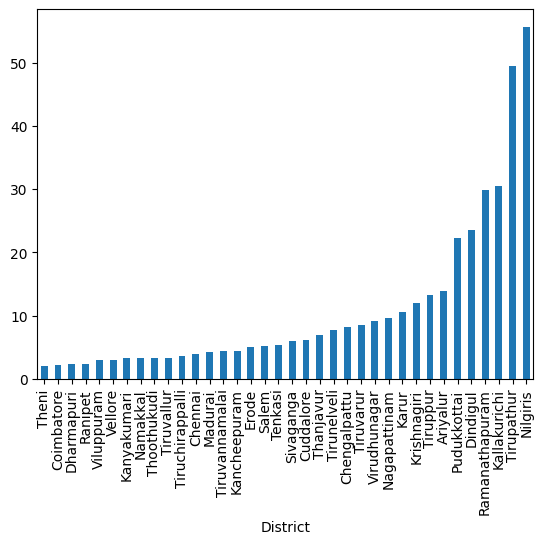

In [437]:
df.groupby('District')['Hourly Rainfall'].mean().sort_values().plot(kind='bar')

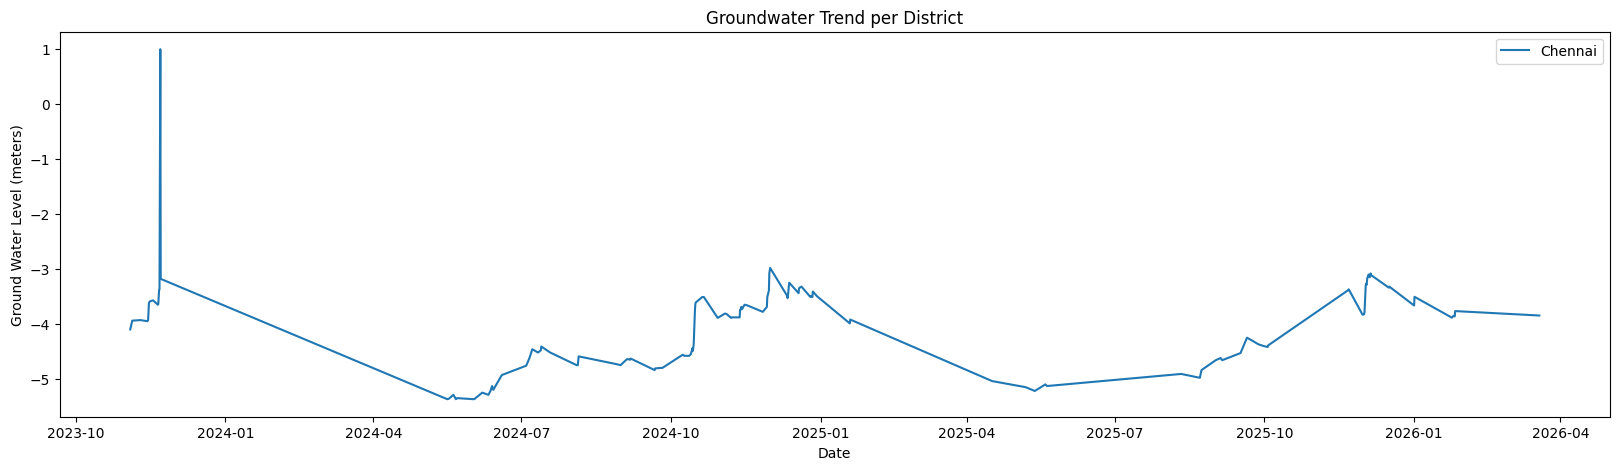

In [438]:
district='Chennai'
df_chennai = df[df['District'] == district]
plt.figure(figsize=(20,5))
plt.plot(df_chennai['Data Acquisition Time'], df_chennai['Ground Water Level'], label=district, )

plt.legend()
plt.title("Groundwater Trend per District")
plt.xlabel("Date")
plt.ylabel("Ground Water Level (meters)")
plt.show()

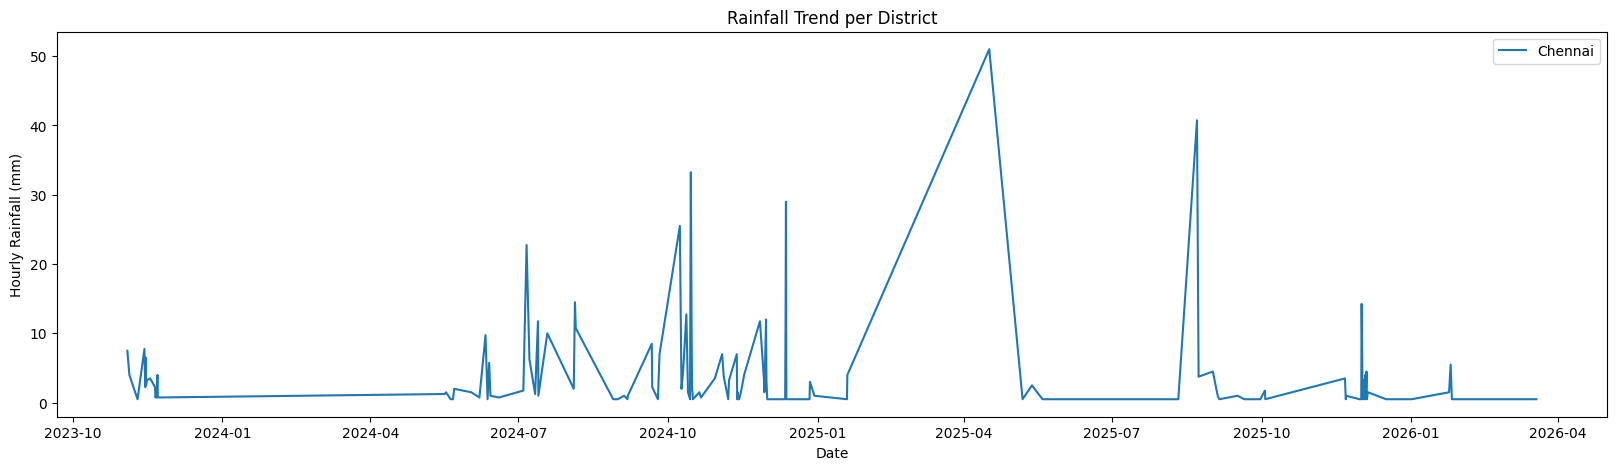

In [439]:
district='Chennai'
df_chennai = df[df['District'] == district]
plt.figure(figsize=(20,5))
plt.plot(df_chennai['Data Acquisition Time'], df_chennai['Hourly Rainfall'], label=district, )

plt.legend()
plt.title("Rainfall Trend per District")
plt.xlabel("Date")
plt.ylabel("Hourly Rainfall (mm)")
plt.show()

<Axes: ylabel='District-None'>

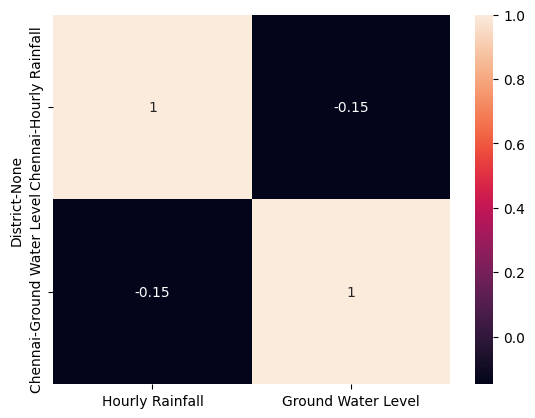

In [440]:
sns.heatmap(df_chennai.groupby('District')[['Hourly Rainfall', 'Ground Water Level']].corr(), annot=True)

<Axes: xlabel='District', ylabel='month'>

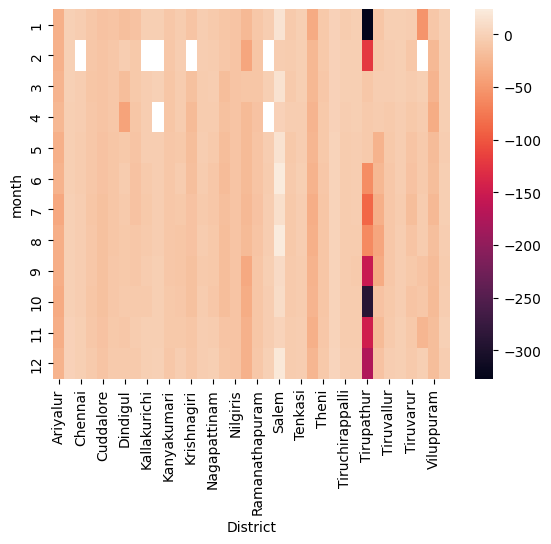

In [441]:
pivot=df.pivot_table(
    index='month',
    columns='District',
    values='Ground Water Level',
    aggfunc='mean'
)

sns.heatmap(pivot)

<Axes: xlabel='Data Acquisition Time', ylabel='Ground Water Level'>

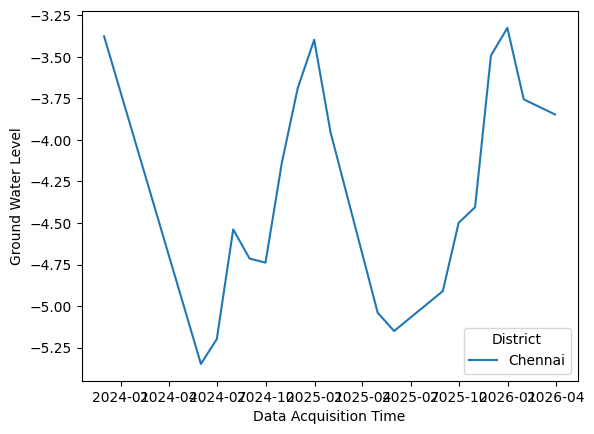

In [442]:
df_monthly = (
    df_chennai.groupby('District')
      .resample('ME', on='Data Acquisition Time')
      .mean()
      .reset_index()
)
sns.lineplot(data=df_monthly, x='Data Acquisition Time', y='Ground Water Level', hue='District')

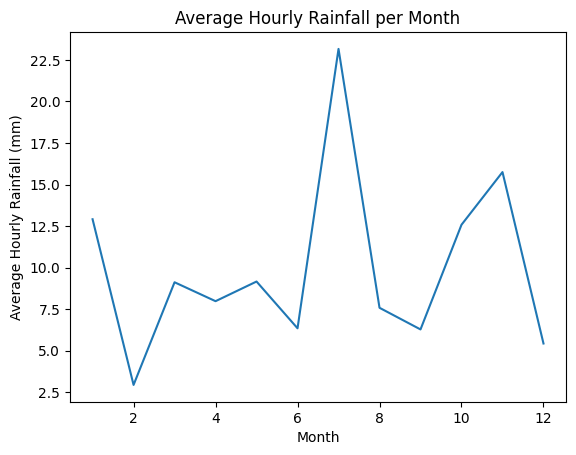

In [443]:
df.groupby('month')['Hourly Rainfall'].mean().plot()
plt.title("Average Hourly Rainfall per Month")
plt.xlabel("Month")
plt.ylabel("Average Hourly Rainfall (mm)")
plt.show()

<Axes: xlabel='District', ylabel='month'>

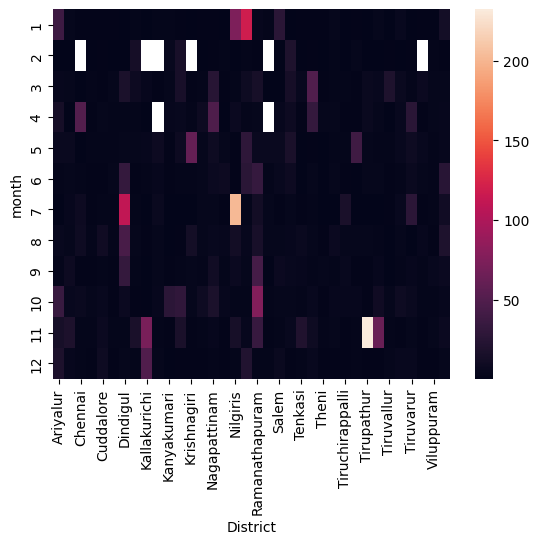

In [444]:
pivot = df.pivot_table(
    index='month',
    columns='District',
    values='Hourly Rainfall',
    aggfunc='mean'
)

sns.heatmap(pivot)

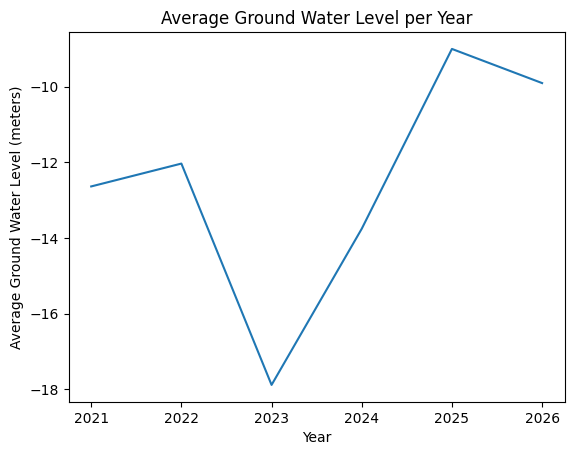

In [445]:
df.groupby('year')['Ground Water Level'].mean().plot()
plt.title("Average Ground Water Level per Year")
plt.xlabel("Year")
plt.ylabel("Average Ground Water Level (meters)")
plt.show()

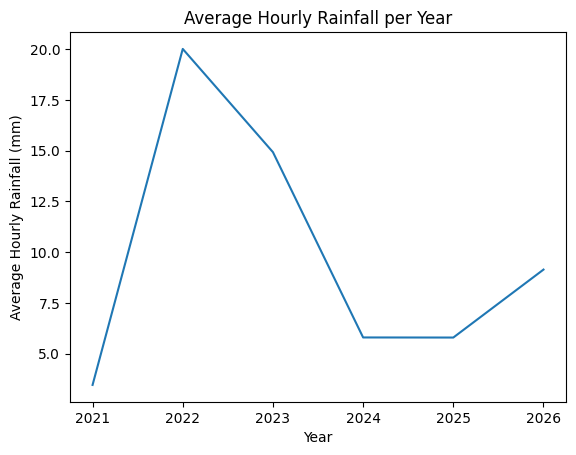

In [446]:
df.groupby('year')['Hourly Rainfall'].mean().plot()
plt.title("Average Hourly Rainfall per Year")
plt.xlabel("Year")
plt.ylabel("Average Hourly Rainfall (mm)")
plt.show()

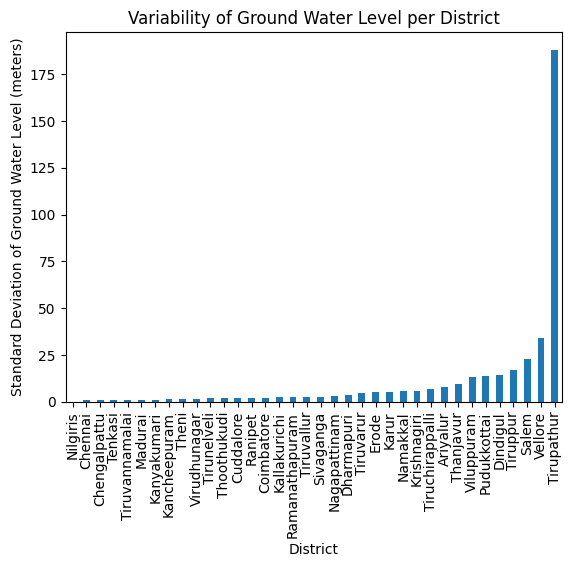

In [447]:
df.groupby('District')['Ground Water Level'].std().sort_values().plot(kind='bar')
plt.title("Variability of Ground Water Level per District")
plt.xlabel("District")
plt.ylabel("Standard Deviation of Ground Water Level (meters)")
plt.show()

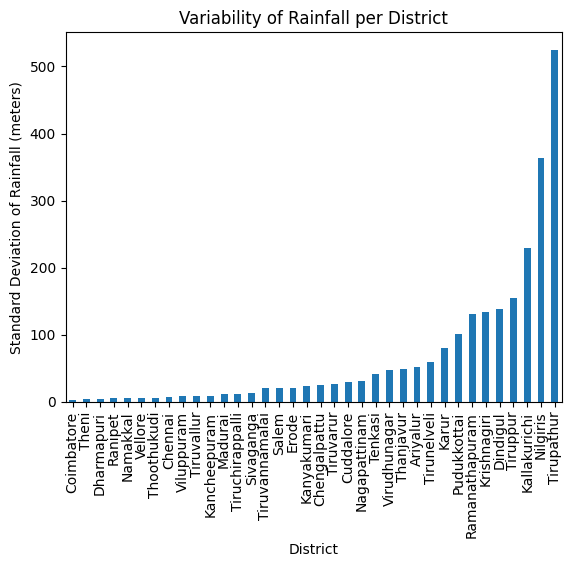

In [448]:
df.groupby('District')['Hourly Rainfall'].std().sort_values().plot(kind='bar')
plt.title("Variability of Rainfall per District")
plt.xlabel("District")
plt.ylabel("Standard Deviation of Rainfall (meters)")
plt.show()

# Lag Features

In [449]:
df['rain_lag_1'] = df.groupby('District LGD Code')['Hourly Rainfall'].shift(1)
df['rain_lag_7'] = df.groupby('District LGD Code')['Hourly Rainfall'].shift(7)

df['gw_lag_1'] = df.groupby('District LGD Code')['Ground Water Level'].shift(1)
df['gw_lag_7'] = df.groupby('District LGD Code')['Ground Water Level'].shift(7)
df['gw_lag_30'] = df.groupby('District LGD Code')['Ground Water Level'].shift(30)

# Rolling Features

In [450]:
df['rain_7day_sum'] = df.groupby('District LGD Code')['Hourly Rainfall'].rolling(7).sum().reset_index(0,drop=True)

df['rain_30day_sum'] = df.groupby('District LGD Code')['Hourly Rainfall'].rolling(30).sum().reset_index(0,drop=True)

# Time Features

In [451]:
df['season'] = (df['month']%12)//3
df['week_of_year'] = df['Data Acquisition Time'].dt.isocalendar().week.astype(int)

# Train Test Split

In [492]:
#df['target'] = df.groupby('District LGD Code')['Ground Water Level'].shift(-7)
df['target'] = df.groupby('District')['Ground Water Level'].shift(-1) - df['Ground Water Level']
df=df.dropna()

In [473]:
len(df['District'].value_counts())

36

In [474]:
df[df['District'] == 'Chennai']['Data Acquisition Time'].describe()

count                           103
mean     2025-03-04 21:26:12.815534
min             2024-07-11 06:00:00
25%             2024-10-15 21:00:00
50%             2024-12-12 00:00:00
75%             2025-09-18 06:00:00
max             2025-12-16 18:00:00
Name: Data Acquisition Time, dtype: object

In [455]:
df.head(10)

,Data Acquisition Time,District LGD Code,District,Hourly Rainfall,Ground Water Level,day,month,year,rain_lag_1,rain_lag_7,gw_lag_1,gw_lag_7,gw_lag_30,rain_7day_sum,rain_30day_sum,season,week_of_year,target
7888,2024-07-11 06:00:00,568,Chennai,1.25,-4.52,11,7,2024,6.25,0.50,-4.46,-5.22,-4.10,39.50,97.50,2,28,-4.73
7909,2024-07-13 00:00:00,568,Chennai,11.75,-4.48,13,7,2024,1.25,5.75,-4.52,-5.13,-3.94,45.50,105.25,2,28,-4.75
7930,2024-07-13 06:00:00,568,Chennai,1.00,-4.41,13,7,2024,11.75,1.00,-4.48,-5.20,-3.93,45.50,105.75,2,28,-4.64
8067,2024-07-18 18:00:00,568,Chennai,10.00,-4.52,18,7,2024,1.00,0.75,-4.41,-4.93,-3.95,54.75,108.00,2,29,-4.65
8186,2024-08-04 00:00:00,568,Chennai,2.00,-4.75,4,8,2024,10.00,1.75,-4.52,-4.76,-3.93,55.00,107.75,2,31,-4.63
8197,2024-08-04 18:00:00,568,Chennai,14.50,-4.75,4,8,2024,2.00,22.75,-4.75,-4.62,-3.79,46.75,115.75,2,31,-4.84
8217,2024-08-05 06:00:00,568,Chennai,10.75,-4.59,5,8,2024,14.50,6.25,-4.75,-4.46,-3.62,51.25,124.00,2,32,-4.81
8572,2024-08-28 06:00:00,568,Chennai,0.50,-4.73,28,8,2024,10.75,1.25,-4.59,-4.52,-3.59,50.50,121.25,2,35,-4.80
8610,2024-08-31 00:00:00,568,Chennai,0.50,-4.75,31,8,2024,0.50,11.75,-4.73,-4.48,-3.57,39.25,118.25,2,35,-4.80
8657,2024-09-04 00:00:00,568,Chennai,1.00,-4.64,4,9,2024,0.50,1.00,-4.75,-4.41,-3.65,39.25,117.00,3,36,-4.56


In [503]:
features = [
    'Hourly Rainfall',
    'Ground Water Level',
    'rain_lag_1',
    'rain_lag_7',
    'rain_7day_sum',
    'rain_30day_sum',
    'gw_lag_1',
    'gw_lag_7',
    'gw_lag_30',
    'season',
    'District',
]

target = 'target'

In [504]:
train = df[df['Data Acquisition Time'] < '2025-06-01']
test = df[df['Data Acquisition Time'] >= '2025-06-01']
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [505]:
le = LabelEncoder()

X_train['District_enc'] = le.fit_transform(X_train['District'])
X_test['District_enc'] = le.transform(X_test['District'])
X_train = X_train.drop(columns=['District'])
X_test = X_test.drop(columns=['District'])

In [507]:
num_cols = X_train.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ]
)

In [508]:
lr_model=LinearRegression()
lr_model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr_model)
])

In [510]:
lr_model_pipeline.fit(X_train, y_train)
y_pred_lr = lr_model_pipeline.predict(X_test)
y_pred_lr = y_pred_lr + X_test['Ground Water Level']
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2 (Linear Regression):", r2_lr)
print("RMSE (Linear Regression):", rmse_lr)

R2 (Linear Regression): -7.290413158592063
RMSE (Linear Regression): 17.065166639610915


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf = y_pred_rf + X_test['Ground Water Level']
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("R2 (Random Forest):", r2_rf)
print("RMSE (Random Forest):", rmse_rf)


In [ ]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = y_pred_xgb + X_test['Ground Water Level']
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("R2 (XGBoost):", r2_xgb)
print("RMSE (XGBoost):", rmse_xgb)

R2 (XGBoost): -8.17097542944372
RMSE (XGBoost): 17.948584797559086


In [ ]:
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_lgbm = y_pred_lgbm + X_test['Ground Water Level']
r2_lgbm = r2_score(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
print("R2 (LightGBM):", r2_lgbm)
print("RMSE (LightGBM):", rmse_lgbm)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2080
[LightGBM] [Info] Number of data points in the train set: 10811, number of used features: 10
[LightGBM] [Info] Start training from score 0.015277
R2 (LightGBM): -8.093295235211697
RMSE (LightGBM): 17.872408902474714


In [486]:
models={'Linear Regression': (lr_model, y_pred_lr, r2_lr, rmse_lr), 'Random Forest': (rf_model, y_pred_rf, r2_rf, rmse_rf),'XGBoost': (xgb_model, y_pred_xgb, r2_xgb, rmse_xgb), 'LightGBM': (lgbm_model, y_pred_lgbm, r2_lgbm, rmse_lgbm)}
for name, (model, y_pred, r2, rmse) in models.items():
    print(f"{name}\nR2: {r2:.4f}, RMSE: {rmse:.4f}")

Linear Regression
R2: -7.3112, RMSE: 16.9955
Random Forest
R2: -7.1208, RMSE: 16.7996
XGBoost
R2: -7.5671, RMSE: 17.2551
LightGBM
R2: -7.3758, RMSE: 17.0613


In [487]:
importances = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

           Feature  Importance
8           season    0.162671
9     District_enc    0.124974
5         gw_lag_1    0.111864
7        gw_lag_30    0.108968
4   rain_30day_sum    0.104295
3    rain_7day_sum    0.100404
6         gw_lag_7    0.094764
2       rain_lag_7    0.088426
1       rain_lag_1    0.065259
0  Hourly Rainfall    0.038375


In [488]:
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coeffs)

           Feature  Coefficient
5         gw_lag_1    -4.200724
6         gw_lag_7     2.997450
7        gw_lag_30    -0.507615
8           season    -0.149539
9     District_enc    -0.136006
4   rain_30day_sum     0.040279
2       rain_lag_7    -0.030736
1       rain_lag_1     0.005947
0  Hourly Rainfall    -0.001422
3    rain_7day_sum    -0.001139
